In [1]:
#!/usr/bin/env python3
"""
Plot heterogeneity results from venue DiD estimation.

Reads CSVs from ../../data/did/merged_{field}_{journal}/
Saves figures to ../../figure/heterogeneity/

Run interactively cell-by-cell, or as a script.
"""

'\nPlot heterogeneity results from venue DiD estimation.\n\nReads CSVs from ../../data/did/merged_{field}_{journal}/\nSaves figures to ../../figure/heterogeneity/\n\nRun interactively cell-by-cell, or as a script.\n'

In [2]:
# %% ── Imports & Config ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import string

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['ytick.left'] = False
plt.rcParams['axes.grid'] = True  # Ensure grid lines are enabled
plt.rcParams['axes.grid.which'] = 'major'  # Apply grid lines only to major ticks
plt.rcParams['axes.grid.axis'] = 'y'  # Only show horizontal grid lines
plt.rcParams['grid.linestyle'] = '--'  # Set grid line style to dashed
plt.rcParams['grid.alpha'] = 0.3  # Set grid line transparency


In [3]:
# ── Palettes ──
COLOR_FEMALE = '#C8A2C8'
COLOR_MALE   = '#6FA8DC'


Plotting heterogeneity for: merged_physics_Nature_l2
Data dir: ../../data/did/merged_physics_Nature_l2
Figure dir: ../../figure/heterogeneity

── Gender ──
  Saved: ../../figure/heterogeneity/merged_physics_Nature_l2_gender_heterogeneity.png
  Saved: ../../figure/heterogeneity/merged_physics_Nature_l2_gender_heterogeneity.pdf


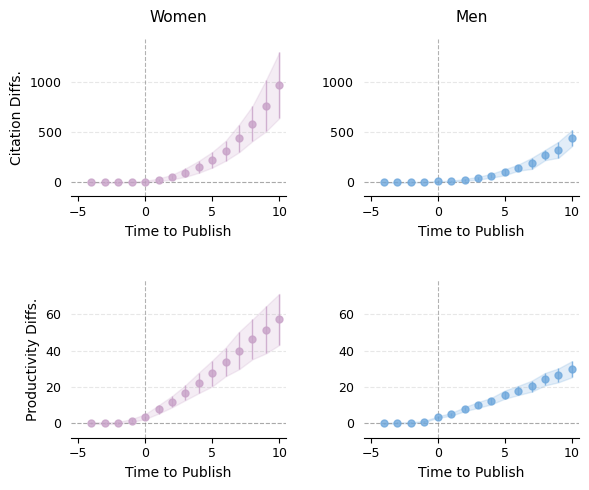


── Career Stage ──
  Saved: ../../figure/heterogeneity/merged_physics_Nature_l2_career_heterogeneity.png
  Saved: ../../figure/heterogeneity/merged_physics_Nature_l2_career_heterogeneity.pdf


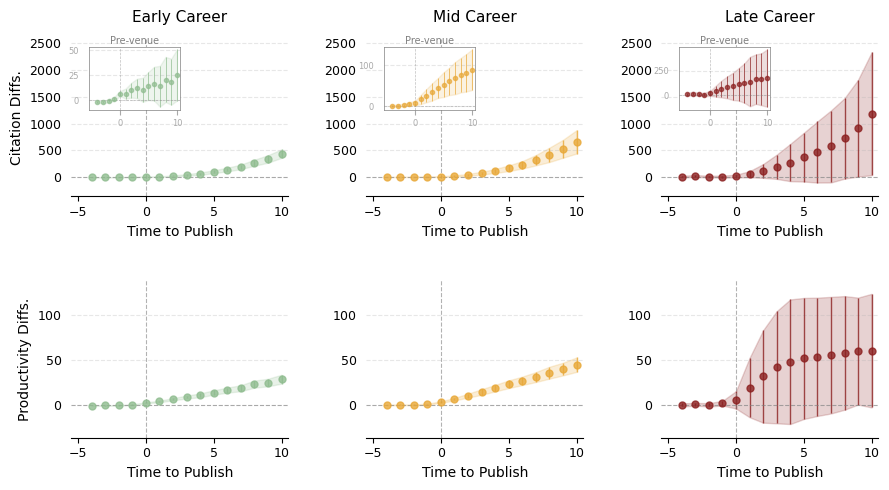


── Region ──
  Saved: ../../figure/heterogeneity/merged_physics_Nature_l2_region_heterogeneity.png
  Saved: ../../figure/heterogeneity/merged_physics_Nature_l2_region_heterogeneity.pdf


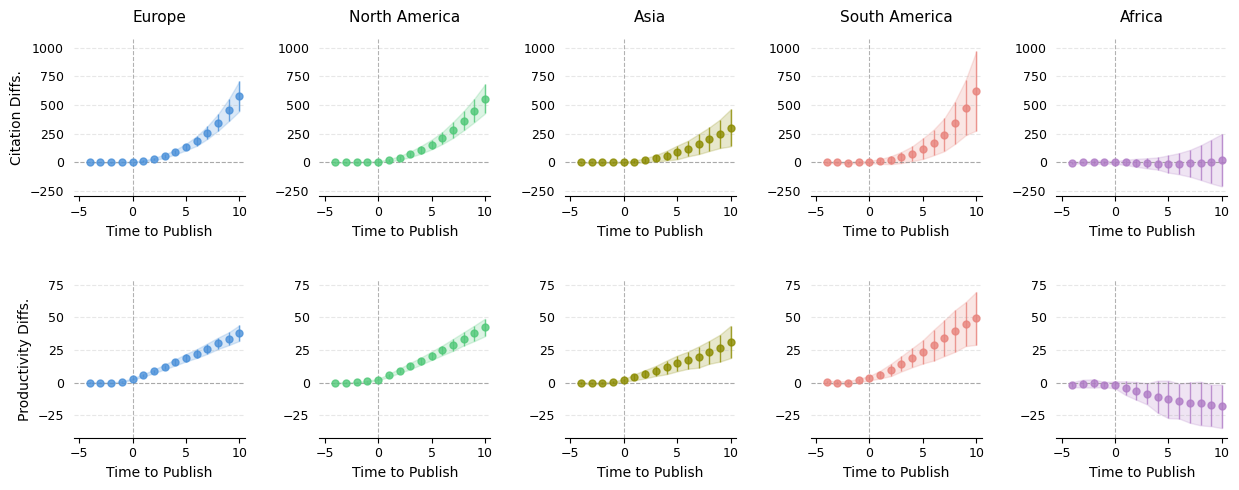


Done!


In [8]:
#!/usr/bin/env python3
"""
Plot heterogeneity results from venue DiD estimation.

Reads CSVs from ../../data/did/merged_{field}_{journal}/
Saves figures to ../../figure/heterogeneity/

Run interactively cell-by-cell, or as a script.
"""

# %% ── Imports & Config ──────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pathlib import Path
import string

# Paths
DID_DIR = Path('../../data/did')
FIG_DIR = Path('../../figure/heterogeneity')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Which field/journal to plot (change as needed)
FIELD_JOURNAL = 'merged_physics_Nature_l2'
DATA_DIR = DID_DIR / FIELD_JOURNAL


# %% ── Helper: load a dynamic CSV ───────────────────────────────────────────

def load_dynamic(filename, data_dir=None):
    """Load a dynamic_*.csv file, return DataFrame sorted by event_time."""
    if data_dir is None:
        data_dir = DATA_DIR
    fpath = Path(data_dir) / filename
    if not fpath.exists():
        print(f'  WARNING: {fpath} not found')
        return pd.DataFrame()
    df = pd.read_csv(fpath)
    if 'event_time' not in df.columns and 'to_year' in df.columns:
        df['event_time'] = df['to_year']
    return df.sort_values('event_time').reset_index(drop=True)


# %% ── Core plotting function ───────────────────────────────────────────────

def plot_att(ax, df, color, label=None, alpha_fill=0.2, alpha_line=0.8,
             marker='o', markersize=5, linewidth=1.5):
    """
    Plot ATT event-study on a single axis.
    Dots with error bars + shaded CI band, dashed zero/treatment lines.
    """
    if df.empty:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                ha='center', va='center', fontsize=10, color='gray')
        return

    e = df['event_time'].values
    att = df['att'].values
    ci_lo = df['ci_lower'].values
    ci_hi = df['ci_upper'].values
    se = df['se'].values

    ax.fill_between(e, ci_lo, ci_hi, color=color, alpha=alpha_fill)
    ax.errorbar(e, att, yerr=1.96 * se, fmt=marker, color=color,
                markersize=markersize, linewidth=linewidth,
                capsize=0, alpha=alpha_line, label=label,
                markeredgecolor=color, markerfacecolor=color,
                elinewidth=1.0)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)


def plot_att_inset(ax_inset, df, color, alpha_fill=0.15, alpha_line=0.7,
                   marker='o', markersize=3, linewidth=1.0):
    """Plot ATT on an inset axis (smaller markers, thinner lines)."""
    if df.empty:
        return
    e = df['event_time'].values
    att = df['att'].values
    ci_lo = df['ci_lower'].values
    ci_hi = df['ci_upper'].values
    se = df['se'].values

    ax_inset.fill_between(e, ci_lo, ci_hi, color=color, alpha=alpha_fill)
    ax_inset.errorbar(e, att, yerr=1.96 * se, fmt=marker, color=color,
                      markersize=markersize, linewidth=linewidth,
                      capsize=0, alpha=alpha_line,
                      markeredgecolor=color, markerfacecolor=color,
                      elinewidth=0.7)
    ax_inset.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax_inset.axvline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)


def style_ax(ax, title='', ylabel='', xlabel='Time to Publish',
             panel_label=None):
    """Apply consistent styling to an axis."""
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='normal', pad=12)
    ax.tick_params(labelsize=9)
    ax.set_xlim(-5.5, 10.5)

    # Panel label (a, b, c, ...) — COMMENTED OUT for now
    # if panel_label:
    #     ax.text(-0.15, 1.15, panel_label, transform=ax.transAxes,
    #             fontsize=13, fontweight='bold', va='top', ha='right')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def sync_ylim_row(axes_row):
    """Set the same y-limits for all axes in a row."""
    ymins, ymaxs = [], []
    for ax in axes_row:
        ylo, yhi = ax.get_ylim()
        if len(ax.lines) > 0 or len(ax.collections) > 0:
            ymins.append(ylo)
            ymaxs.append(yhi)
    if ymins and ymaxs:
        shared_lo = min(ymins)
        shared_hi = max(ymaxs)
        pad = (shared_hi - shared_lo) * 0.05
        for ax in axes_row:
            ax.set_ylim(shared_lo - pad, shared_hi + pad)


def add_inset(ax, df_inset, color, inset_title='Pre-venue',
              bounds=[0.08, 0.55, 0.42, 0.40]):
    """
    Add an inset plot (pre-venue citations) inside the main axes.

    bounds: [left, bottom, width, height] in axes-fraction coordinates.
    Default places it in the upper-left area.
    """
    if df_inset.empty:
        return None

    ax_ins = ax.inset_axes(bounds)
    ax_ins.set_facecolor('white')      # ← add this
    ax_ins.patch.set_alpha(1.0)        # ← add this
    plot_att_inset(ax_ins, df_inset, color=color)

    ax_ins.set_xlim(-5.5, 10.5)

    # x/y tick labels and tick marks in grey
    ax_ins.tick_params(axis='both', labelsize=6, colors='darkgray')

    # inset title in grey
    ax_ins.set_title(inset_title, fontsize=7, pad=2, color='gray')

    # all inset axis spines in grey
    for spine in ax_ins.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color('gray')

    return ax_ins


# %% ── 1. GENDER HETEROGENEITY ──────────────────────────────────────────────
# 2 rows (Citations, Productivity) × 2 cols (Women, Men)
# Pre-venue citations as inset in Citations row

def plot_gender(field_journal=FIELD_JOURNAL, save=True):
    data_dir = DID_DIR / field_journal

    # Main outcomes: rows
    main_outcomes = [
        ('cum_citations_na',       'Citation Diffs.'),
        ('cum_publication_count',  'Productivity Diffs.'),
    ]
    # Inset outcome (shown inside the citations row)
    inset_outcome = 'cum_citations_old'  # pre-venue citations
    genders = [
        ('female', 'Women',  COLOR_FEMALE),
        ('male',   'Men',    COLOR_MALE),
    ]
    nrows = len(main_outcomes)
    ncols = len(genders)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3 * ncols, 2.5 * nrows),
                             squeeze=False)

    for row, (outcome, ylabel) in enumerate(main_outcomes):
        for col, (gval, glabel, gcolor) in enumerate(genders):
            ax = axes[row, col]
            fname = f'dynamic_{outcome}_gender_{gval}.csv'
            df = load_dynamic(fname, data_dir)
            plot_att(ax, df, color=gcolor)

            ylabel_show = ylabel if col == 0 else ''
            style_ax(ax, title=glabel if row == 0 else '',
                     ylabel=ylabel_show)

            # # Add inset for pre-venue citations in the citations row
            # if outcome == 'cum_citations_na':
            #     fname_inset = f'dynamic_{inset_outcome}_gender_{gval}.csv'
            #     df_inset = load_dynamic(fname_inset, data_dir)
            #     add_inset(ax, df_inset, color=gcolor,
            #               inset_title='Pre-venue')

        sync_ylim_row(axes[row, :])

    fig.tight_layout(w_pad=2.5, h_pad=3.0)
    # fig.patch.set_alpha(0)
    for ax_row in axes:
        for ax in ax_row:
            ax.patch.set_alpha(0)

    if save:
        for ext in ['png', 'pdf']:
            out = FIG_DIR / f'{field_journal}_gender_heterogeneity.{ext}'
            fig.savefig(out, dpi=300, bbox_inches='tight', transparent=True)
            print(f'  Saved: {out}')

    plt.show()
    return fig


# %% ── 2. CAREER STAGE HETEROGENEITY ────────────────────────────────────────
# 2 rows (Citations, Productivity) × 3 cols (Early, Mid, Late)
# Pre-venue citations as inset in Citations row

def plot_career(field_journal=FIELD_JOURNAL, save=True):
    data_dir = DID_DIR / field_journal

    main_outcomes = [
        ('cum_citations_na',       'Citation Diffs.'),
        ('cum_publication_count',  'Productivity Diffs.'),
    ]
    inset_outcome = 'cum_citations_old'

    stages = [
        ('early-career', 'Early Career', '#8FBC8F'),
        ('mid-career',   'Mid Career',   '#E8A838'),
        ('late-career',  'Late Career',  '#8B2020'),
    ]

    nrows = len(main_outcomes)
    ncols = len(stages)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3 * ncols, 2.5 * nrows),
                             squeeze=False)

    for row, (outcome, ylabel) in enumerate(main_outcomes):
        for col, (cval, clabel, ccolor) in enumerate(stages):
            ax = axes[row, col]
            fname = f'dynamic_{outcome}_career_{cval}.csv'
            df = load_dynamic(fname, data_dir)
            plot_att(ax, df, color=ccolor)

            ylabel_show = ylabel if col == 0 else ''
            style_ax(ax, title=clabel if row == 0 else '',
                     ylabel=ylabel_show)

            if outcome == 'cum_citations_na':
                fname_inset = f'dynamic_{inset_outcome}_career_{cval}.csv'
                df_inset = load_dynamic(fname_inset, data_dir)
                add_inset(ax, df_inset, color=ccolor,
                          inset_title='Pre-venue')

        sync_ylim_row(axes[row, :])

    fig.tight_layout(w_pad=2.5, h_pad=3.0)
    fig.patch.set_alpha(0)
    for ax_row in axes:
        for ax in ax_row:
            if not hasattr(ax, '_inset_axes_parent'):
                ax.patch.set_alpha(0)

    if save:
        for ext in ['png', 'pdf']:
            out = FIG_DIR / f'{field_journal}_career_heterogeneity.{ext}'
            fig.savefig(out, dpi=300, bbox_inches='tight', transparent=False)
            print(f'  Saved: {out}')

    plt.show()
    return fig


# %% ── 3. REGION HETEROGENEITY ──────────────────────────────────────────────
# 2 rows (Citations, Productivity) × up to 6 cols
# Pre-venue citations as inset in Citations row

def plot_region(field_journal=FIELD_JOURNAL, save=True):
    data_dir = DID_DIR / field_journal

    main_outcomes = [
        ('cum_citations_na',       'Citation Diffs.'),
        ('cum_publication_count',  'Productivity Diffs.'),
    ]
    inset_outcome = 'cum_citations_old'

    regions = [
        ('Europe',                              'Europe',         '#4A90D9'),
        ('Northern_America',                    'North America',  '#50C878'),
        ('Asia',                                'Asia',           '#8B8B00'),
        ('Latin_America_and_the_Caribbean',     'South America',  '#E8837C'),
        ('Africa',                              'Africa',         '#B07CC6')
        # ('Oceania',                             'Oceania',        '#A0A0A0'),
    ]

    # Filter to regions that have data
    available_regions = []
    for rsuffix, rlabel, rcolor in regions:
        for outcome, _ in main_outcomes:
            fname = f'dynamic_{outcome}_region_{rsuffix}.csv'
            if (data_dir / fname).exists():
                available_regions.append((rsuffix, rlabel, rcolor))
                break

    if not available_regions:
        print('  No region data found!')
        return None

    ncols = len(available_regions)
    nrows = len(main_outcomes)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(2.5 * ncols, 2.5 * nrows),
                             squeeze=False)

    for row, (outcome, ylabel) in enumerate(main_outcomes):
        for col, (rsuffix, rlabel, rcolor) in enumerate(available_regions):
            ax = axes[row, col]
            fname = f'dynamic_{outcome}_region_{rsuffix}.csv'
            df = load_dynamic(fname, data_dir)
            plot_att(ax, df, color=rcolor)

            ylabel_show = ylabel if col == 0 else ''
            style_ax(ax, title=rlabel if row == 0 else '',
                     ylabel=ylabel_show)

            # if outcome == 'cum_citations_na':
            #     fname_inset = f'dynamic_{inset_outcome}_region_{rsuffix}.csv'
            #     df_inset = load_dynamic(fname_inset, data_dir)
            #     add_inset(ax, df_inset, color=rcolor,
            #               inset_title='Pre-venue')

        sync_ylim_row(axes[row, :])

    fig.tight_layout(w_pad=2.0, h_pad=3.0)
    # fig.patch.set_alpha(0)
    for ax_row in axes:
        for ax in ax_row:
            if not hasattr(ax, '_inset_axes_parent'):
                ax.patch.set_alpha(0)

    if save:
        for ext in ['png', 'pdf']:
            out = FIG_DIR / f'{field_journal}_region_heterogeneity.{ext}'
            fig.savefig(out, dpi=300, bbox_inches='tight', transparent=True)
            print(f'  Saved: {out}')

    plt.show()
    return fig


# %% ── Run all plots ────────────────────────────────────────────────────────

if __name__ == '__main__':
    print(f'\nPlotting heterogeneity for: {FIELD_JOURNAL}')
    print(f'Data dir: {DATA_DIR}')
    print(f'Figure dir: {FIG_DIR}\n')

    print('── Gender ──')
    plot_gender()

    print('\n── Career Stage ──')
    plot_career()

    print('\n── Region ──')
    plot_region()

    print('\nDone!')


# %% ── Batch: all field/journal combinations ────────────────────────────────

def plot_all():
    """Plot heterogeneity for all field/journal combos found in DID_DIR."""
    dirs = sorted([d for d in DID_DIR.iterdir() if d.is_dir()])
    print(f'Found {len(dirs)} result directories\n')

    for d in dirs:
        fj = d.name
        print(f'\n{"="*60}')
        print(f'  {fj}')
        print(f'{"="*60}')

        dyn_files = list(d.glob('dynamic_*.csv'))
        if not dyn_files:
            print('  No dynamic files found, skipping.')
            continue

        try:
            plot_gender(fj)
        except Exception as e:
            print(f'  Gender plot failed: {e}')

        try:
            plot_career(fj)
        except Exception as e:
            print(f'  Career plot failed: {e}')

        try:
            plot_region(fj)
        except Exception as e:
            print(f'  Region plot failed: {e}')

# Uncomment to run all:
# plot_all()

Fig dir  : ../../figure/heterogeneity
Exclude  : {2013}


  Nature (merged_physics_Nature_l2)
  Available cohort files: 9

  -- General citations --
  -> merged_physics_Nature_l2_cohort_general_citations.pdf
  -> merged_physics_Nature_l2_cohort_general_citations.png


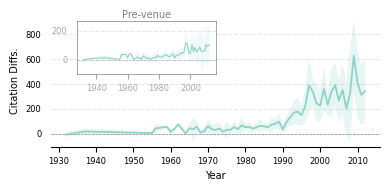


  -- General productivity --
  -> merged_physics_Nature_l2_cohort_general_productivity.pdf
  -> merged_physics_Nature_l2_cohort_general_productivity.png


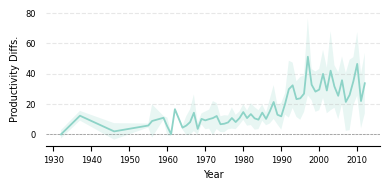


  Science (merged_physics_Science_l2)
  Available cohort files: 9

  -- General citations --
  -> merged_physics_Science_l2_cohort_general_citations.pdf
  -> merged_physics_Science_l2_cohort_general_citations.png


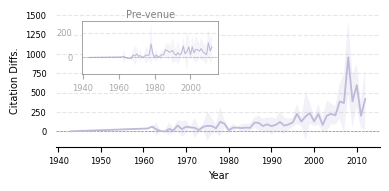


  -- General productivity --
  -> merged_physics_Science_l2_cohort_general_productivity.pdf
  -> merged_physics_Science_l2_cohort_general_productivity.png


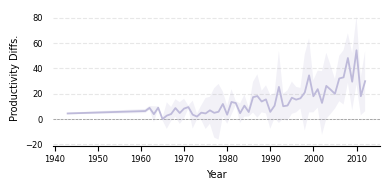


  Gender (merged_physics_Nature_l2)

  -- Gender citations --
  -> merged_physics_Nature_l2_cohort_gender_citations.pdf
  -> merged_physics_Nature_l2_cohort_gender_citations.png


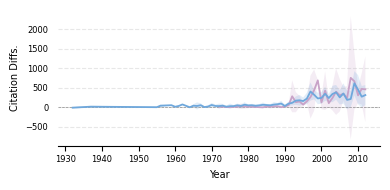


  -- Gender productivity --
  -> merged_physics_Nature_l2_cohort_gender_productivity.pdf
  -> merged_physics_Nature_l2_cohort_gender_productivity.png


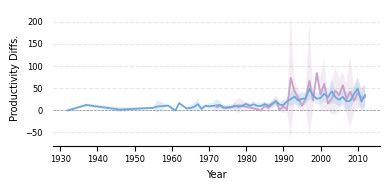


All done.


In [2]:
"""
Cohort heterogeneity plots for venue effect analysis.
─────────────────────────────────────────────────────
General panels (per journal):
  - Citations  (inset: citations_old)
  - Productivity

Gender panels (FIELD_JOURNAL only):
  - Citations  (inset: citations_old by gender)
  - Productivity

Style: line + filled 95% CI (att ± 1.96*se). No titles, no legends.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['ytick.left'] = False
plt.rcParams['axes.grid'] = True  # Ensure grid lines are enabled
plt.rcParams['axes.grid.which'] = 'major'  # Apply grid lines only to major ticks
plt.rcParams['axes.grid.axis'] = 'y'  # Only show horizontal grid lines
plt.rcParams['grid.linestyle'] = '--'  # Set grid line style to dashed
plt.rcParams['grid.alpha'] = 0.3  # Set grid line transparency


# ── Configuration ──────────────────────────────────────────────────────
DID_DIR = Path('../../data/did_dynamic')
FIG_DIR = Path('../../figure/heterogeneity')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Default field/journal for gender plots
FIELD_JOURNAL = 'merged_physics_Nature_l2'

# ── Journal registry (for general cohort plots) ───────────────────────
#    Each journal gets a fixed Set3 color:
#      Nature  → Set3[0]
#      Science → Set3[2]  (skip index 1)
SET3 = plt.cm.Set3.colors

JOURNALS = [
    ('merged_physics_Nature_l2',  'Nature',  SET3[0]),
    ('merged_physics_Science_l2', 'Science', SET3[2]),
]

# Inset color (shared across all journals)
COLOR_GENERAL_OLD = 'yellowgreen'

# ── Gender palette (unchanged) ────────────────────────────────────────
COLOR_FEMALE = '#C8A2C8'       # lilac
COLOR_MALE   = '#6FA8DC'       # soft blue

genders = [
    ('female', 'Women',  COLOR_FEMALE),
    ('male',   'Men',    COLOR_MALE),
]

ALPHA_FILL       = 0.20
ALPHA_FILL_INSET = 0.15
MIN_YEAR         = 1930
EXCLUDE_YEARS    = {2013}
# FIGSIZE          = (4, 2)
FIGSIZE          = (4, 2)

# ── I/O helpers ────────────────────────────────────────────────────────
def _load(metric, field_journal, gender_suffix=''):
    fname = f'cohort_{metric}{gender_suffix}.csv'
    fpath = DID_DIR / field_journal / fname
    if not fpath.exists():
        print(f"  [skip] {fname} not found in {field_journal}")
        return pd.DataFrame()
    df = pd.read_csv(fpath).sort_values('group').reset_index(drop=True)
    df = df[df['group'] >= MIN_YEAR]
    df = df[~df['group'].isin(EXCLUDE_YEARS)]
    return df.copy()


def _load_old(field_journal, gender_suffix=''):
    fname = f'cohort_cum_citations_old{gender_suffix}.csv'
    fpath = DID_DIR / field_journal / fname
    if not fpath.exists():
        print(f"  [skip] {fname} not found in {field_journal}")
        return pd.DataFrame()
    df = pd.read_csv(fpath).sort_values('group').reset_index(drop=True)
    df = df[df['group'] >= MIN_YEAR]
    df = df[~df['group'].isin(EXCLUDE_YEARS)]
    return df.copy()


# ── Drawing helpers ────────────────────────────────────────────────────
def _draw(ax, df, color, lw=1.3, label=None):
    """Line + shaded CI (att ± 1.96*se). No markers."""
    x   = df['group'].values
    y   = df['att'].values
    se  = df['se'].values
    lo  = y - 1.96 * se
    hi  = y + 1.96 * se
    ax.fill_between(x, lo, hi, color=color, alpha=ALPHA_FILL, edgecolor='none')
    ax.plot(x, y, color=color, linewidth=lw, label=label)


def _style(ax, xlabel='Year', ylabel=''):
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', zorder=0)
    ax.set_xlabel(xlabel, fontsize=7)
    ax.set_ylabel(ylabel, fontsize=7)
    ax.tick_params(labelsize=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def _add_inset(ax, df_inset, color, inset_title='Pre-venue',
               bounds=[0.08, 0.55, 0.42, 0.40]):
    if df_inset.empty:
        return None

    ins = ax.inset_axes(bounds)

    x  = df_inset['group'].values
    y  = df_inset['att'].values
    se = df_inset['se'].values
    lo = y - 1.96 * se
    hi = y + 1.96 * se

    ins.fill_between(x, lo, hi, color=color, alpha=ALPHA_FILL_INSET,
                     edgecolor='none')
    ins.plot(x, y, color=color, linewidth=0.8)
    ins.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    ins.tick_params(axis='both', labelsize=6, colors='darkgray')
    ins.set_title(inset_title, fontsize=7, pad=2, color='gray')

    for spine in ins.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color('gray')

    return ins


def _save_and_show(fig, stem):
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    for ext in ['pdf', 'png']:
        out = FIG_DIR / f'{stem}.{ext}'
        fig.savefig(out, dpi=900, bbox_inches='tight')
        print(f"  -> {out.name}")
    plt.show()
    plt.close(fig)


# ══════════════════════════════════════════════════════════════════════
#  General cohort: Citations + Productivity — per journal
# ══════════════════════════════════════════════════════════════════════
def plot_general_citations(field_journal, color):
    df = _load('cum_citations_na', field_journal)
    if df.empty:
        return
    df_old = _load_old(field_journal)

    fig, ax = plt.subplots(figsize=FIGSIZE)
    _draw(ax, df, color)
    _style(ax, ylabel='Citation Diffs.')

    if not df_old.empty:
        _add_inset(ax, df_old, color, inset_title='Pre-venue')

    _save_and_show(fig, f'{field_journal}_cohort_general_citations')


def plot_general_productivity(field_journal, color):
    df = _load('cum_publication_count_adj', field_journal)
    if df.empty:
        return

    fig, ax = plt.subplots(figsize=FIGSIZE)
    _draw(ax, df, color)
    _style(ax, ylabel='Productivity Diffs.')

    _save_and_show(fig, f'{field_journal}_cohort_general_productivity')


# ══════════════════════════════════════════════════════════════════════
#  Gender cohort: Citations + Productivity — FIELD_JOURNAL only
# ══════════════════════════════════════════════════════════════════════
def plot_gender_citations():
    dfs = {}
    for gsuf, glabel, gcolor in genders:
        dfs[gsuf] = _load('cum_citations_na', FIELD_JOURNAL,
                          f'_gender_{gsuf}')

    if all(d.empty for d in dfs.values()):
        return

    dfs_old = {}
    for gsuf, glabel, gcolor in genders:
        dfs_old[gsuf] = _load_old(FIELD_JOURNAL, f'_gender_{gsuf}')

    fig, ax = plt.subplots(figsize=FIGSIZE)

    for gsuf, glabel, gcolor in genders:
        if not dfs[gsuf].empty:
            _draw(ax, dfs[gsuf], gcolor)

    _style(ax, ylabel='Citation Diffs.')

    # # inset: pre-venue citations_old by gender
    # if any(not dfs_old[g].empty for g, _, _ in genders):
    #     ins = None
    #     for gsuf, glabel, gcolor in genders:
    #         if not dfs_old[gsuf].empty:
    #             if ins is None:
    #                 ins = _add_inset(ax, dfs_old[gsuf], gcolor,
    #                                  inset_title='Pre-venue')
    #             else:
    #                 x  = dfs_old[gsuf]['group'].values
    #                 y  = dfs_old[gsuf]['att'].values
    #                 se = dfs_old[gsuf]['se'].values
    #                 lo = y - 1.96 * se
    #                 hi = y + 1.96 * se
    #                 ins.fill_between(x, lo, hi, color=gcolor,
    #                                  alpha=ALPHA_FILL_INSET, edgecolor='none')
    #                 ins.plot(x, y, color=gcolor, linewidth=0.8)

    _save_and_show(fig, f'{FIELD_JOURNAL}_cohort_gender_citations')


def plot_gender_productivity():
    dfs = {}
    for gsuf, glabel, gcolor in genders:
        dfs[gsuf] = _load('cum_publication_count_adj', FIELD_JOURNAL,
                          f'_gender_{gsuf}')

    if all(d.empty for d in dfs.values()):
        return

    fig, ax = plt.subplots(figsize=FIGSIZE)

    for gsuf, glabel, gcolor in genders:
        if not dfs[gsuf].empty:
            _draw(ax, dfs[gsuf], gcolor)

    _style(ax, ylabel='Productivity Diffs.')

    _save_and_show(fig, f'{FIELD_JOURNAL}_cohort_gender_productivity')


# ══════════════════════════════════════════════════════════════════════
#  Run all
# ══════════════════════════════════════════════════════════════════════
if __name__ == '__main__':
    print(f"Fig dir  : {FIG_DIR}")
    print(f"Exclude  : {EXCLUDE_YEARS}\n")

    # ── General cohort: per journal ──
    for fj, jlabel, jcolor in JOURNALS:
        dd = DID_DIR / fj
        print(f"\n{'='*50}")
        print(f"  {jlabel} ({fj})")
        print(f"{'='*50}")

        if dd.exists():
            fs = sorted(dd.glob('cohort_*.csv'))
            print(f"  Available cohort files: {len(fs)}")
        else:
            print(f"  WARNING: {dd} not found")
            continue

        print(f"\n  -- General citations --")
        plot_general_citations(fj, jcolor)

        print(f"\n  -- General productivity --")
        plot_general_productivity(fj, jcolor)

    # ── Gender cohort: FIELD_JOURNAL only ──
    print(f"\n{'='*50}")
    print(f"  Gender ({FIELD_JOURNAL})")
    print(f"{'='*50}")

    print("\n  -- Gender citations --")
    plot_gender_citations()

    print("\n  -- Gender productivity --")
    plot_gender_productivity()

    print("\nAll done.")

  -> merged_physics_Nature_l2_exposure_general_special_citations.pdf
  -> merged_physics_Nature_l2_exposure_general_special_citations.png


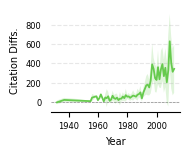

In [19]:
# ── Special one-off plot ───────────────────────────────────────────────
SPECIAL_FIELD_JOURNAL = 'merged_physics_Nature_l2'
COLOR_GENERAL_SPECIAL = '#66CA4D'
FIGSIZE_SPECIAL = (3/1.5, 2/1.2)   # (2.0, 1.666...)


def plot_general_special():
    """
    Special general cohort plot:
    - only Nature physics
    - only cum_citations_na
    - custom green color
    - smaller figsize
    """
    df = _load('cum_citations_na', SPECIAL_FIELD_JOURNAL)
    if df.empty:
        return

    fig, ax = plt.subplots(figsize=FIGSIZE_SPECIAL)
    _draw(ax, df, COLOR_GENERAL_SPECIAL)
    _style(ax, ylabel='Citation Diffs.')

    _save_and_show(fig, f'{SPECIAL_FIELD_JOURNAL}_exposure_general_special_citations')

plot_general_special()

In [3]:
# %% ── Special: general exposure effect (Nature physics, citations only) ──

SPECIAL_FIELD_JOURNAL = 'merged_physics_Nature_l2'
COLOR_GENERAL_SPECIAL = '#66CA4D'
FIGSIZE_SPECIAL = (2.5, 2)

def plot_general_special(field_journal=SPECIAL_FIELD_JOURNAL, save=True):
    data_dir = DID_DIR / field_journal

    fname = 'dynamic_cum_citations_na.csv'
    df = load_dynamic(fname, data_dir)

    if df.empty:
        print(f'  No data found for {fname} in {data_dir}')
        return None

    fig, ax = plt.subplots(figsize=FIGSIZE_SPECIAL)

    plot_att(ax, df, color=COLOR_GENERAL_SPECIAL)
    style_ax(ax, ylabel='',xlabel='')

    fig.tight_layout()
    # fig.patch.set_alpha(0)
    # ax.patch.set_alpha(0)

    if save:
        for ext in ['png', 'pdf']:
            out = FIG_DIR / f'{field_journal}_general_special_citations.{ext}'
            fig.savefig(out, dpi=600, bbox_inches='tight', transparent=True)
            print(f'  Saved: {out}')

    plt.show()
    return fig


  -- Combined citations (Nature + Science) --
  -> combined_cohort_general_citations.pdf
  -> combined_cohort_general_citations.png


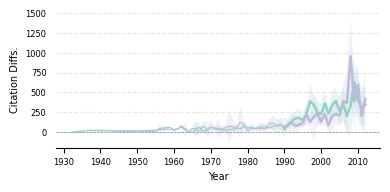


  -- Combined productivity (Nature + Science) --
  -> combined_cohort_general_productivity.pdf
  -> combined_cohort_general_productivity.png


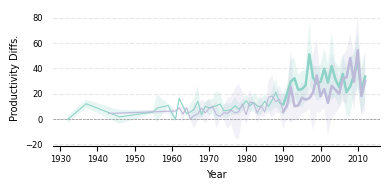

In [4]:
# ══════════════════════════════════════════════════════════════════════
#  General cohort: Nature + Science overlaid in one figure
#  Add this after the existing per-journal plots
# ══════════════════════════════════════════════════════════════════════

def _draw(ax, df, color, lw=1.3, label=None, solid_after=1990):
    """Line + shaded CI. Dashed before solid_after, solid after."""
    x   = df['group'].values
    y   = df['att'].values
    se  = df['se'].values
    lo  = y - 1.96 * se
    hi  = y + 1.96 * se
    ax.fill_between(x, lo, hi, color=color, alpha=ALPHA_FILL, edgecolor='none')

    if solid_after is not None:
        mask_dash  = x <= solid_after
        mask_solid = x >= solid_after  # overlap at boundary for seamless join
        if mask_dash.any():
            ax.plot(x[mask_dash], y[mask_dash], color=color,
                    linewidth=lw-0.5, linestyle='-', label=label)
        if mask_solid.any():
            ax.plot(x[mask_solid], y[mask_solid], color=color,
                    linewidth=lw+0.5, linestyle='-')
    else:
        ax.plot(x, y, color=color, linewidth=lw, label=label)

def plot_combined_citations():
    """Citations cohort: all journals overlaid, inset also overlaid."""
    fig, ax = plt.subplots(figsize=FIGSIZE)

    # Main curves
    for fj, jlabel, jcolor in JOURNALS:
        df = _load('cum_citations_na', fj)
        if not df.empty:
            _draw(ax, df, jcolor)

    _style(ax, ylabel='Citation Diffs.')

    # # Inset: pre-venue citations_old, all journals overlaid
    # ins = None
    # for fj, jlabel, jcolor in JOURNALS:
    #     df_old = _load_old(fj)
    #     if df_old.empty:
    #         continue
    #     if ins is None:
    #         ins = _add_inset(ax, df_old, jcolor, inset_title='Pre-venue')
    #     else:
    #         x  = df_old['group'].values
    #         y  = df_old['att'].values
    #         se = df_old['se'].values
    #         lo = y - 1.96 * se
    #         hi = y + 1.96 * se
    #         ins.fill_between(x, lo, hi, color=jcolor,
    #                          alpha=ALPHA_FILL_INSET, edgecolor='none')
    #         ins.plot(x, y, color=jcolor, linewidth=0.8)

    _save_and_show(fig, 'combined_cohort_general_citations')


def plot_combined_productivity():
    """Productivity cohort: all journals overlaid."""
    fig, ax = plt.subplots(figsize=FIGSIZE)

    for fj, jlabel, jcolor in JOURNALS:
        df = _load('cum_publication_count_adj', fj)
        if not df.empty:
            _draw(ax, df, jcolor)

    _style(ax, ylabel='Productivity Diffs.')

    _save_and_show(fig, 'combined_cohort_general_productivity')


# ── Run combined ──
if __name__ == '__main__':
    print("\n  -- Combined citations (Nature + Science) --")
    plot_combined_citations()

    print("\n  -- Combined productivity (Nature + Science) --")
    plot_combined_productivity()

## plot the general effect bars

Saved science to ../../figure


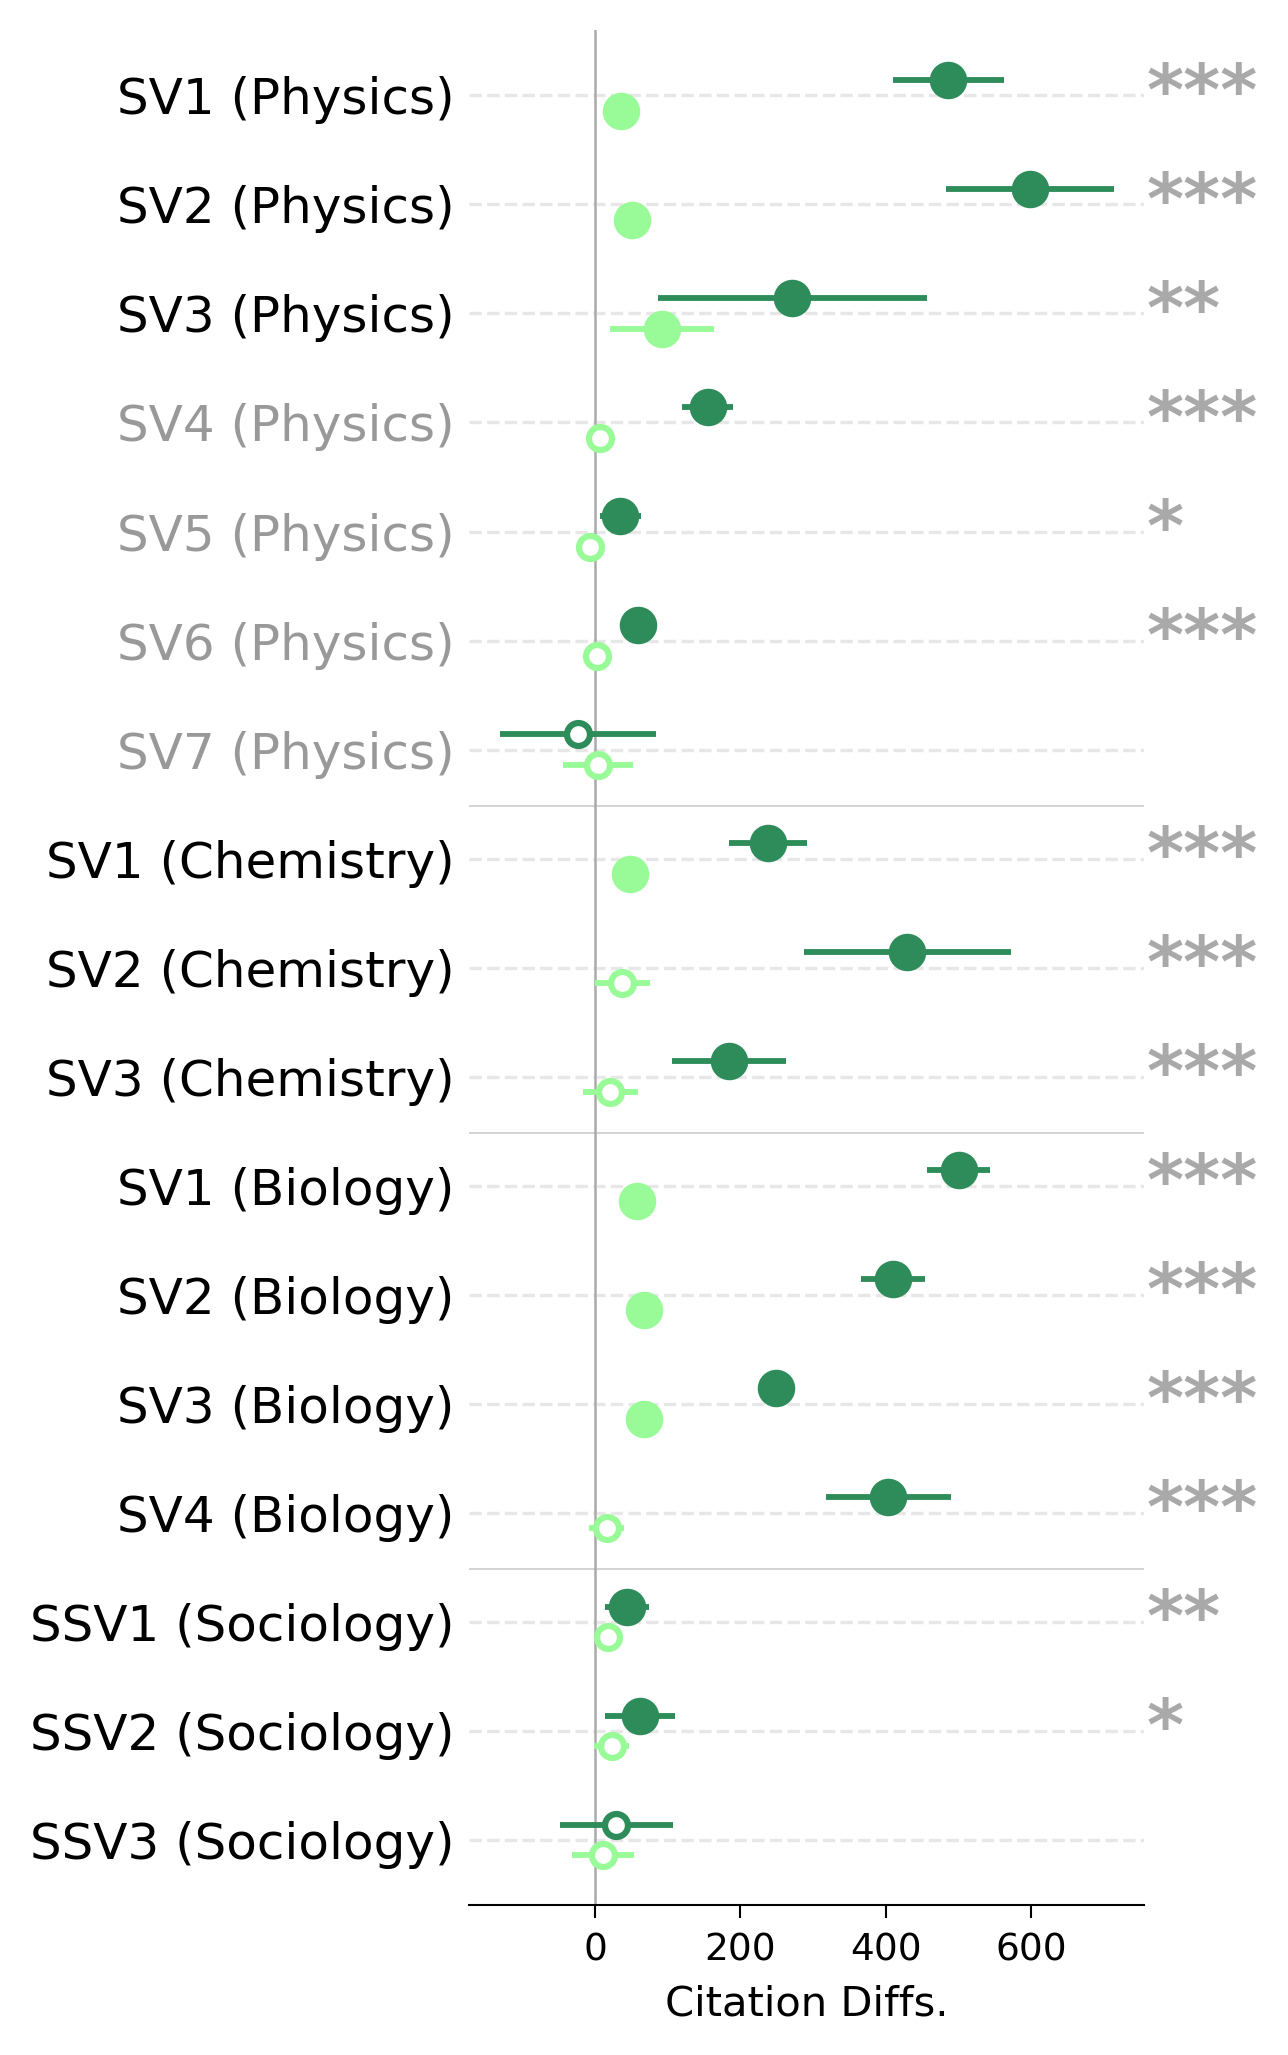


Science plot values:
           label            series     att     se  ci_lower  ci_upper  pvalue stars  grey_label
   SV1 (Physics)  cum_citations_na 486.403 38.886   410.185   562.620   0.000   ***       False
   SV1 (Physics) cum_citations_old  35.635 12.423    11.286    59.985   0.004    **       False
   SV2 (Physics)  cum_citations_na 599.042 58.749   483.894   714.190   0.000   ***       False
   SV2 (Physics) cum_citations_old  50.880 11.444    28.450    73.310   0.000   ***       False
   SV3 (Physics)  cum_citations_na 271.424 94.657    85.896   456.952   0.004    **       False
   SV3 (Physics) cum_citations_old  91.940 36.611    20.182   163.699   0.012     *       False
   SV4 (Physics)  cum_citations_na 154.782 17.915   119.668   189.895   0.000   ***        True
   SV4 (Physics) cum_citations_old   6.308  4.985    -3.462    16.079   0.206              True
   SV5 (Physics)  cum_citations_na  34.702 14.424     6.432    62.972   0.016     *        True
   SV5 (Physics) c

In [1]:
#!/usr/bin/env python3
"""
Venue Effect — Horizontal Errorbar Plot (Science + Art)
"""

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path


plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['ytick.left'] = False
plt.rcParams['axes.grid'] = True  # Ensure grid lines are enabled
plt.rcParams['axes.grid.which'] = 'major'  # Apply grid lines only to major ticks
plt.rcParams['axes.grid.axis'] = 'y'  # Only show horizontal grid lines
plt.rcParams['grid.linestyle'] = '--'  # Set grid line style to dashed
plt.rcParams['grid.alpha'] = 0.3  # Set grid line transparency

# =============================================================================
# *** CHANGE THESE ***
# =============================================================================

EVENT_TIME = 10              # <-- change to 10 for 10-year ATT
SAVE_FIGS  = True
OUTPUT_DIR = '../../figure'

# =============================================================================
# SCIENCE config
# =============================================================================

SCI_DID_BASE = Path('../../data/did')

SCI_VENUES = [
    ('merged_physics_Nature_l2',          'SV1 (Physics)',    False),
    ('merged_physics_Science_l2',         'SV2 (Physics)',    False),
    ('merged_physics_PNAS_l2',            'SV3 (Physics)',    False),
    ('merged_physics_PRL_l2',             'SV4 (Physics)',    True),
    ('merged_physics_PRA_l2',             'SV5 (Physics)',    True),
    ('merged_physics_PRB_l2',             'SV6 (Physics)',    True),
    ('merged_physics_PRC_l2',             'SV7 (Physics)',    True),
    ('merged_chemistry_Nature_l2',           'SV1 (Chemistry)', False),
    ('merged_chemistry_Science_l2',          'SV2 (Chemistry)', False),
    ('merged_chemistry_PNAS_l2',             'SV3 (Chemistry)', False),
    ('merged_biology_Nature_l2',   'SV1 (Biology)',   False),
    ('merged_biology_Science_l2',  'SV2 (Biology)',   False),
    ('merged_biology_PNAS_l2',     'SV3 (Biology)',   False),
    ('merged_biology_Cell_l2',     'SV4 (Biology)',   False),

    ('merged_sociology_ASR_l2',              'SSV1 (Sociology)', False),
    ('merged_sociology_AJS_l2',              'SSV2 (Sociology)', False),
    ('merged_sociology_ESR_l2',              'SSV3 (Sociology)', False),
]

SCI_DISCIPLINE_GROUPS = {
    'Physics':    (0, 7),
    'Chemistry':  (7, 10),
    'Biology':    (10, 14),
    'Sociology':  (14, 17),
}

SCI_OUTCOMES = ['cum_citations_na', 'cum_citations_old']
SCI_COLORS = {
    'cum_citations_na':  '#2D8C5A',
    'cum_citations_old': 'palegreen',
}

# =============================================================================
# ART config
# =============================================================================

ART_DID_BASE = Path('../../data/did_art')

ART_VENUES = [
    ('matched_venice_biennale',      'AV1 (Venice)'),
    ('matched_documenta',            'AV2 (Documenta)'),
    ('matched_bienal_sao_paulo',     'AV3 (São Paulo)'),
    ('matched_whitney_biennial',     'AV4 (Whitney)'),
    ('matched_biennale_of_sydney',   'AV5 (Sydney)'),
    ('matched_istanbul_biennial',    'AV6 (Istanbul)'),
    ('matched_manifesta',            'AV7 (Manifesta)'),
    ('matched_gwangju_biennale',     'AV8 (Gwangju)'),
]

ART_OUTCOMES = ['S', 'G']
ART_COLORS = {
    'S': '#2D8C5A',
    'G': 'palegreen',
}


# =============================================================================
# Helpers
# =============================================================================

def load_att(did_base, file_label, outcome, event_time):
    csv_path = did_base / file_label / f'dynamic_{outcome}.csv'
    if not csv_path.exists():
        return None, None, None
    df = pd.read_csv(csv_path)
    col = 'event_time' if 'event_time' in df.columns else 'to_year'
    if col not in df.columns:
        return None, None, None
    row = df[df[col] == event_time]
    if row.empty:
        return None, None, None
    r = row.iloc[0]
    return float(r.get('att', np.nan)), float(r.get('se', np.nan)), float(r.get('pvalue', np.nan))


def sig_stars(pv):
    """Return significance stars string."""
    if pv is None or np.isnan(pv):
        return ''
    if pv < 0.001:
        return '***'
    if pv < 0.01:
        return '**'
    if pv < 0.05:
        return '*'
    return ''


def best_pvalue(row, outcomes):
    """Return the most significant p-value across outcomes for a row."""
    pvs = []
    for oc in outcomes:
        pv = row.get(f'{oc}_pv')
        if pv is not None and not np.isnan(pv):
            pvs.append(pv)
    return min(pvs) if pvs else None

def make_plot_table(data, outcomes, include_grey=False):
    rows = []
    for row in data:
        for oc in outcomes:
            att = row.get(f'{oc}_att')
            se  = row.get(f'{oc}_se')
            pv  = row.get(f'{oc}_pv')

            if att is None or pd.isna(att):
                continue

            ci = 1.96 * se if se is not None and not pd.isna(se) else np.nan

            out = {
                'label': row['label'],
                'series': oc,
                'att': att,
                'se': se,
                'ci_lower': att - ci if not pd.isna(ci) else np.nan,
                'ci_upper': att + ci if not pd.isna(ci) else np.nan,
                'pvalue': pv,
                'stars': sig_stars(pv),
            }

            if include_grey:
                out['grey_label'] = row.get('grey_label', False)

            rows.append(out)

    return pd.DataFrame(rows)
# =============================================================================
# Science plot
# =============================================================================

def plot_science(event_time=EVENT_TIME, save=SAVE_FIGS):
    n = len(SCI_VENUES)
    data = []
    for folder, label, grey_label in SCI_VENUES:
        row = {'label': label, 'grey_label': grey_label}
        for oc in SCI_OUTCOMES:
            att, se, pv = load_att(SCI_DID_BASE, folder, oc, event_time)
            row[f'{oc}_att'] = att
            row[f'{oc}_se'] = se
            row[f'{oc}_pv'] = pv
        data.append(row)

    fig_h = n * 0.35 + 1.0
    fig, ax = plt.subplots(figsize=(5, fig_h), dpi=300)
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    y_pos = np.arange(n)[::-1]
    off = 0.14

    # # Discipline labels + separators
    for disc, (i0, i1) in SCI_DISCIPLINE_GROUPS.items():
    #     y_top = y_pos[i0] + 0.48
    #     y_bot = y_pos[i1 - 1] - 0.48
    #     y_mid = (y_top + y_bot) / 2
    #     ax.text(1.015, y_mid, disc, transform=ax.get_yaxis_transform(),
    #             ha='left', va='center', fontsize=9.5, fontweight='bold',
    #             color='#555555', fontstyle='italic')
        if i0 > 0:
            ax.axhline(y_pos[i0] + 0.48, color='#CCCCCC', linewidth=0.4, zorder=1)

    ax.axvline(0, color='#AAAAAA', linewidth=0.6, zorder=1)

    # Track x-range for star placement
    x_max = 0

    for i, row in enumerate(data):
        y = y_pos[i]
        for j, oc in enumerate(SCI_OUTCOMES):
            att = row.get(f'{oc}_att')
            se  = row.get(f'{oc}_se')
            pv  = row.get(f'{oc}_pv')
            if att is None:
                continue
            y_off = y + off if j == 0 else y - off
            ci = 1.96 * se if se and not np.isnan(se) else 0
            sig = pv is not None and not np.isnan(pv) and pv < 0.05
            ax.errorbar(att, y_off, xerr=ci, fmt='none',
                        ecolor=SCI_COLORS[oc], elinewidth=1.4, capsize=0, zorder=2)
            ax.plot(att, y_off, 'o',
                    color=SCI_COLORS[oc] if sig else 'white',
                    markeredgecolor=SCI_COLORS[oc],
                    markersize=7.5 if sig else 5.5,
                    markeredgewidth=1.5, zorder=3)
            x_max = max(x_max, att + ci)

    # Significance stars — placed at fixed x position to the right
    x_star = x_max * 1.05 + 10  # small offset beyond data
    for i, row in enumerate(data):
        y = y_pos[i]
        # Use the overall (na) p-value for the star
        pv_na = row.get(f'{SCI_OUTCOMES[0]}_pv')
        stars = sig_stars(pv_na)
        if stars:
            ax.text(x_star, y, stars, ha='left', va='center',
                    fontsize=17, color='darkgrey', fontweight='bold')

    ax.set_yticks(y_pos)
    tick_labels = ax.set_yticklabels([d['label'] for d in data], fontsize=12)
    for i, tl in enumerate(tick_labels):
        if data[i]['grey_label']:
            tl.set_color('#999999')

    ax.set_ylim(y_pos[-1] - 0.6, y_pos[0] + 0.6)
    ax.set_xlabel("Citation Diffs.")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', length=3, width=0.5, labelsize=9)

    fig.tight_layout(rect=[0, 0, 0.88, 1])

    if save:
        out = Path(OUTPUT_DIR)
        out.mkdir(parents=True, exist_ok=True)
        fig.savefig(out / f'{event_time}yr_att_science.png',
                    dpi=300, bbox_inches='tight', transparent=True)
        fig.savefig(out / f'{event_time}yr_att_science.pdf',
                    bbox_inches='tight', transparent=True)
        print(f'Saved science to {out}')

    plt.show()

    df_table = make_plot_table(data, SCI_OUTCOMES, include_grey=True)
    print("\nScience plot values:")
    print(df_table.round(3).to_string(index=False))
    return fig


# =============================================================================
# Art plot
# =============================================================================

def plot_art(event_time=EVENT_TIME, save=SAVE_FIGS):
    n = len(ART_VENUES)
    data = []
    for folder, label in ART_VENUES:
        row = {'label': label}
        for oc in ART_OUTCOMES:
            att, se, pv = load_att(ART_DID_BASE, folder, oc, event_time)
            row[f'{oc}_att'] = att
            row[f'{oc}_se'] = se
            row[f'{oc}_pv'] = pv
        data.append(row)

    fig_h = n * 0.35 + 1.0
    fig, ax = plt.subplots(figsize=(5, fig_h), dpi=300)
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    y_pos = np.arange(n)[::-1]
    off = 0.14

    ax.axvline(0, color='#AAAAAA', linewidth=0.6, zorder=1)

    x_max = 0

    for i, row in enumerate(data):
        y = y_pos[i]
        for j, oc in enumerate(ART_OUTCOMES):
            att = row.get(f'{oc}_att')
            se  = row.get(f'{oc}_se')
            pv  = row.get(f'{oc}_pv')
            if att is None:
                continue
            y_off = y + off if j == 0 else y - off
            ci = 1.96 * se if se and not np.isnan(se) else 0
            sig = pv is not None and not np.isnan(pv) and pv < 0.05
            ax.errorbar(att, y_off, xerr=ci, fmt='none',
                        ecolor=ART_COLORS[oc], elinewidth=1.4, capsize=0, zorder=2)
            ax.plot(att, y_off, 'o',
                    color=ART_COLORS[oc] if sig else 'white',
                    markeredgecolor=ART_COLORS[oc],
                    markersize=7.5 if sig else 5.5,
                    markeredgewidth=1.5, zorder=3)
            x_max = max(x_max, att + ci)

    # Significance stars — use Solo (S) p-value
    x_star = x_max * 1.05 + 0.5
    for i, row in enumerate(data):
        y = y_pos[i]
        pv_s = row.get(f'{ART_OUTCOMES[0]}_pv')
        stars = sig_stars(pv_s)
        if stars:
            ax.text(x_star, y, stars, ha='left', va='center',
                    fontsize=17, color='darkgrey', fontweight='bold')

    ax.set_yticks(y_pos)
    ax.set_yticklabels([d['label'] for d in data], fontsize=12)

    ax.set_ylim(y_pos[-1] - 0.6, y_pos[0] + 0.6)
    ax.set_xlabel("Exhibition Diffs.")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', length=3, width=0.5, labelsize=9)

    fig.tight_layout(rect=[0, 0, 0.88, 1])

    if save:
        out = Path(OUTPUT_DIR)
        out.mkdir(parents=True, exist_ok=True)
        fig.savefig(out / f'{event_time}yr_att_art.png',
                    dpi=300, bbox_inches='tight', transparent=True)
        fig.savefig(out / f'{event_time}yr_att_art.pdf',
                    bbox_inches='tight', transparent=True)
        print(f'Saved art to {out}')

    plt.show()
    return fig


# =============================================================================
# Run
# =============================================================================

if __name__ == '__main__':
    plot_science()
    # plot_art()